# F1 Pit Strategy Prediction via Semi-Supervised Learning & Active Learning

This notebook builds a lap-level feature matrix from the Ergast Formula 1 (1950-2024) Kaggle
dataset, engineers pit-stop features, assigns rule-based strategy labels (Standard, Undercut,
Overcut, Emergency), and compares a supervised baseline against two semi-supervised approaches:
**Pseudo Labeling** and **Active Learning**.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_curve, auc)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = "data/"

## 1. Data Loading & Feature Engineering

### 1.1 Download & Inspect

We load the raw relational CSVs and take a first look at shapes, dtypes, and missing values.
The key join keys across this dataset are `raceId`, `driverId`, `constructorId` and `circuitId`.

In [2]:
files = {
    "races": "races.csv",
    "pit_stops": "pit_stops.csv",
    "lap_times": "lap_times.csv",
    "results": "results.csv",
    "driver_standings": "driver_standings.csv",
    "constructor_standings": "constructor_standings.csv",
    "constructors": "constructors.csv",
    "drivers": "drivers.csv",
    "circuits": "circuits.csv",
}

dfs = {}
for name, fname in files.items():
    path = os.path.join(DATA_DIR, fname)
    dfs[name] = pd.read_csv(path, na_values=["\\N"])

races, pit_stops, lap_times = dfs["races"], dfs["pit_stops"], dfs["lap_times"]
results, driver_standings, constructor_standings = dfs["results"], dfs["driver_standings"], dfs["constructor_standings"]
constructors, drivers, circuits = dfs["constructors"], dfs["drivers"], dfs["circuits"]

In [3]:
for name, df in dfs.items():
    print(f"--- {name} ---")
    print("shape:", df.shape)
    print(df.dtypes)
    print("missing values:\n", df.isna().sum()[df.isna().sum() > 0])
    display(df.head(3))
    print()

--- races ---
shape: (1125, 18)
raceId          int64
year            int64
round           int64
circuitId       int64
name           object
date           object
time           object
url            object
fp1_date       object
fp1_time       object
fp2_date       object
fp2_time       object
fp3_date       object
fp3_time       object
quali_date     object
quali_time     object
sprint_date    object
sprint_time    object
dtype: object
missing values:
 time            731
fp1_date       1035
fp1_time       1057
fp2_date       1035
fp2_time       1057
fp3_date       1053
fp3_time       1072
quali_date     1035
quali_time     1057
sprint_date    1107
sprint_time    1110
dtype: int64


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- pit_stops ---
shape: (11371, 7)
raceId           int64
driverId         int64
stop             int64
lap              int64
time            object
duration        object
milliseconds     int64
dtype: object
missing values:
 Series([], dtype: int64)


,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426



--- lap_times ---
shape: (589081, 6)
raceId           int64
driverId         int64
lap              int64
position         int64
time            object
milliseconds     int64
dtype: object
missing values:
 Series([], dtype: int64)


...

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...



--- drivers ---
shape: (861, 9)
driverId         int64
driverRef       object
number         float64
code            object
forename        object
surname         object
dob             object
nationality     object
url             object
dtype: object
missing values:
 number    802
code      757
dtype: int64


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg



--- circuits ---
shape: (77, 9)
circuitId       int64
circuitRef     object
name           object
location       object
country        object
lat           float64
lng           float64
alt             int64
url            object
dtype: object
missing values:
 Series([], dtype: int64)


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.9680,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.7380,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.5106,7,http://en.wikipedia.org/wiki/Bahrain_Internati...


### 1.2 Join the Tables

We filter to the 2014-2024 seasons (the modern hybrid/Pirelli era, which is when pit strategy
became highly tactical) and build one row per pit stop with: pit lap, stop duration, grid
position, running position on the pit lap, constructor, circuit, year, and championship points
**before** the race (looked up via the previous race for that driver/constructor).

In [4]:
races_modern = races[(races["year"] >= 2014) & (races["year"] <= 2024)].copy()
races_modern = races_modern.sort_values(["year", "round"]).reset_index(drop=True)

# map each raceId to the previous raceId in chronological order (across the full races table,
# so round 1 of a season correctly points to the last round of the previous season)
races_all_sorted = races.sort_values(["year", "round"]).reset_index(drop=True)
races_all_sorted["prev_raceId"] = races_all_sorted["raceId"].shift(1)
race_prev_map = races_all_sorted.set_index("raceId")["prev_raceId"].to_dict()

races_modern["prev_raceId"] = races_modern["raceId"].map(race_prev_map)

In [5]:
race_total_laps = lap_times.groupby("raceId")["lap"].max().rename("race_total_laps").reset_index()

pit = pit_stops[pit_stops["raceId"].isin(races_modern["raceId"])].copy()
pit = pit.rename(columns={"lap": "pit_lap", "milliseconds": "stop_duration_ms"})

pit = pit.merge(
    races_modern[["raceId", "year", "round", "circuitId", "name", "prev_raceId"]]
        .rename(columns={"name": "race_name"}),
    on="raceId", how="left"
)
pit = pit.merge(race_total_laps, on="raceId", how="left")
pit = pit.merge(circuits[["circuitId", "name"]].rename(columns={"name": "circuit_name"}),
                on="circuitId", how="left")

# grid position + constructor from results
res_slim = results[["raceId", "driverId", "constructorId", "grid", "positionOrder"]].copy()
pit = pit.merge(res_slim, on=["raceId", "driverId"], how="left")
pit = pit.merge(constructors[["constructorId", "name"]].rename(columns={"name": "constructor_name"}),
                 on="constructorId", how="left")
pit = pit.merge(drivers[["driverId", "driverRef", "forename", "surname"]], on="driverId", how="left")

# current running position on the pit lap itself, from lap_times
lt_slim = lap_times.rename(columns={"lap": "pit_lap"})[["raceId", "driverId", "pit_lap", "position", "milliseconds"]]
pit = pit.merge(lt_slim.rename(columns={"position": "position_on_pit_lap", "milliseconds": "lap_time_ms"}),
                 on=["raceId", "driverId", "pit_lap"], how="left")

# championship points BEFORE this race (from the previous race's standings)
ds_slim = driver_standings[["raceId", "driverId", "points"]].rename(columns={"raceId": "prev_raceId", "points": "driver_points_before"})
cs_slim = constructor_standings[["raceId", "constructorId", "points"]].rename(columns={"raceId": "prev_raceId", "points": "constructor_points_before"})
pit = pit.merge(ds_slim, on=["prev_raceId", "driverId"], how="left")
pit = pit.merge(cs_slim, on=["prev_raceId", "constructorId"], how="left")
pit[["driver_points_before", "constructor_points_before"]] = pit[["driver_points_before", "constructor_points_before"]].fillna(0)

print(pit.shape)
pit.head()

(8360, 25)


,raceId,driverId,stop,pit_lap,time,duration,stop_duration_ms,year,round,circuitId,...,grid,positionOrder,constructor_name,driverRef,forename,surname,position_on_pit_lap,lap_time_ms,driver_points_before,constructor_points_before
0,900,154,1,1,17:09:56,17.255,17255,2014,1,1,...,22,15,Lotus F1,grosjean,Romain,Grosjean,17,130795,132.0,315.0
1,900,821,1,1,17:10:12,32.657,32657,2014,1,1,...,20,12,Sauber,gutierrez,Esteban,Gutiérrez,19,161894,6.0,57.0
2,900,815,1,1,17:10:14,25.541,25541,2014,1,1,...,16,10,Force India,perez,Sergio,Pérez,18,156707,49.0,77.0
3,900,18,1,11,17:26:02,22.411,22411,2014,1,1,...,10,3,McLaren,button,Jenson,Button,9,117843,73.0,122.0
4,900,815,2,11,17:27:03,22.497,22497,2014,1,1,...,16,10,Force India,perez,Sergio,Pérez,17,129463,49.0,77.0


### 1.3 Engineer Lap Level Features

#### Part A — Required Features

- **lap_time_delta**: pit-lap time minus the driver's personal best lap time in that race (large
  positive = tyre degradation / trouble on that lap).
- **laps_since_last_pit**: laps since the driver's previous stop (or since race start for the
  first stop) — a proxy for tyre age.
- **laps_remaining**: race laps left after this stop.
- **approx_gap_ahead / approx_gap_behind**: built from cumulative race time per driver up to the
  pit lap, using the running order (`position_on_pit_lap`) to find the neighbouring cars.
- **safety_car_likely**: flag when many drivers on the same lap are unusually slow relative to
  their own race pace (a proxy for SC/VSC, since we don't have official flag data).

In [6]:
pb = lap_times.groupby(["raceId", "driverId"])["milliseconds"].min().rename("personal_best_ms").reset_index()
pit = pit.merge(pb, on=["raceId", "driverId"], how="left")
pit["lap_time_delta"] = pit["lap_time_ms"] - pit["personal_best_ms"]

In [7]:
pit = pit.sort_values(["raceId", "driverId", "pit_lap"]).reset_index(drop=True)
pit["prev_pit_lap"] = pit.groupby(["raceId", "driverId"])["pit_lap"].shift(1)
pit["laps_since_last_pit"] = np.where(pit["prev_pit_lap"].isna(),
                                       pit["pit_lap"],
                                       pit["pit_lap"] - pit["prev_pit_lap"])
pit["laps_remaining"] = pit["race_total_laps"] - pit["pit_lap"]

In [8]:
# cumulative race time per driver per lap, used to approximate time gaps between cars
lap_times_sorted = lap_times.sort_values(["raceId", "driverId", "lap"]).copy()
lap_times_sorted["cum_ms"] = lap_times_sorted.groupby(["raceId", "driverId"])["milliseconds"].cumsum()

cum_lookup = lap_times_sorted[["raceId", "driverId", "lap", "cum_ms", "position"]].rename(
    columns={"lap": "pit_lap"})

pit = pit.merge(cum_lookup[["raceId", "driverId", "pit_lap", "cum_ms"]],
                 on=["raceId", "driverId", "pit_lap"], how="left")

# for every raceId/pit_lap, rank cars by cumulative time so we can grab neighbours by position
def add_gap_features(df, cum_lookup):
    df = df.copy()
    df["approx_gap_ahead"] = np.nan
    df["approx_gap_behind"] = np.nan
    for (race_id, lap), idx in df.groupby(["raceId", "pit_lap"]).groups.items():
        snapshot = cum_lookup[(cum_lookup["raceId"] == race_id) & (cum_lookup["pit_lap"] == lap)]
        snapshot = snapshot.dropna(subset=["cum_ms"]).sort_values("cum_ms").reset_index(drop=True)
        pos_to_ms = dict(zip(snapshot.index, snapshot["cum_ms"]))
        driver_to_rank = dict(zip(snapshot["driverId"], snapshot.index))
        for i in idx:
            drv = df.at[i, "driverId"]
            if drv not in driver_to_rank:
                continue
            rank = driver_to_rank[drv]
            my_ms = pos_to_ms[rank]
            if rank - 1 in pos_to_ms:
                df.at[i, "approx_gap_ahead"] = (my_ms - pos_to_ms[rank - 1]) / 1000.0
            if rank + 1 in pos_to_ms:
                df.at[i, "approx_gap_behind"] = (pos_to_ms[rank + 1] - my_ms) / 1000.0
    return df

pit = add_gap_features(pit, cum_lookup)

> **Note:** the gap computation above loops per (race, lap) group rather than doing a fully
> vectorised merge, because each pit lap needs the *entire field's* running order on that lap to
> find who is directly ahead/behind. On the full 2014-2024 pit stop set this is a few thousand
> groups, so it runs in well under a minute — but if you want it faster, you can vectorise it by
> sorting `cum_lookup` within each `(raceId, pit_lap)` group and using `shift(1)`/`shift(-1)`
> directly on the sorted group instead of the explicit loop.

In [9]:
pit = pit.drop(columns=["safety_car_likely"], errors="ignore")

pit_lap_flags = pit_stops[["raceId", "driverId", "lap"]].drop_duplicates()
pit_lap_flags["is_pit_lap"] = True

lap_stats = lap_times.merge(pit_lap_flags, on=["raceId", "driverId", "lap"], how="left")
lap_stats["is_pit_lap"] = lap_stats["is_pit_lap"].fillna(False)

clean_laps = lap_stats[~lap_stats["is_pit_lap"]].copy()
clean_laps["driver_median_ms"] = clean_laps.groupby(["raceId", "driverId"])["milliseconds"].transform("median")
clean_laps["slow_flag"] = clean_laps["milliseconds"] > 1.15 * clean_laps["driver_median_ms"]

sc_by_lap = clean_laps.groupby(["raceId", "lap"])["slow_flag"].sum().rename("n_slow_drivers").reset_index()
sc_by_lap["safety_car_likely"] = (sc_by_lap["n_slow_drivers"] >= 10).astype(int)

pit = pit.merge(sc_by_lap[["raceId", "lap", "safety_car_likely"]].rename(columns={"lap": "pit_lap"}),
                 on=["raceId", "pit_lap"], how="left")
pit["safety_car_likely"] = pit["safety_car_likely"].fillna(0).astype(int)

C:\Users\Asus\AppData\Local\Temp\ipykernel_4904\2621364702.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lap_stats["is_pit_lap"] = lap_stats["is_pit_lap"].fillna(False)


#### Part B — Open-Ended Bonus Features (bonus)

Two additional engineered features:

1. **`gap_ahead_trend`** — the change in `approx_gap_ahead` over the 3 laps before the stop
   (gap 3 laps ago minus gap now). A large *positive* value means the driver has been closing on
   the car ahead right before pitting — exactly the setup for an **undercut** attempt. F1 teams
   watch this "closing rate" live on timing screens before calling a driver in.
2. **`position_deficit`** — `grid` position minus `position_on_pit_lap`. A large positive value
   means the driver has already lost places since the start (under pressure, more likely to take
   a risk/emergency-style call); a large negative value means they've gained places and may be
   comfortable enough to **overcut** (stay out, defend track position) rather than pit reactively.

In [10]:
gap3_lookup = cum_lookup[["raceId", "driverId", "pit_lap", "cum_ms"]].rename(
    columns={"pit_lap": "lap_minus3", "cum_ms": "cum_ms_minus3"})

pit["lap_minus3"] = pit["pit_lap"] - 3
pit = pit.merge(gap3_lookup, on=["raceId", "driverId", "lap_minus3"], how="left")

pit_gap_hist = pit[["raceId", "driverId", "lap_minus3"]].rename(columns={"lap_minus3": "pit_lap"})
tmp = add_gap_features(pit_gap_hist, cum_lookup)
pit["approx_gap_ahead_minus3"] = tmp["approx_gap_ahead"].values

pit["gap_ahead_trend"] = pit["approx_gap_ahead_minus3"] - pit["approx_gap_ahead"]
pit["position_deficit"] = pit["grid"] - pit["position_on_pit_lap"]

pit = pit.drop(columns=["lap_minus3", "approx_gap_ahead_minus3", "cum_ms_minus3", "cum_ms"],errors="ignore")

C:\Users\Asus\AppData\Local\Temp\ipykernel_4904\2948341368.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)


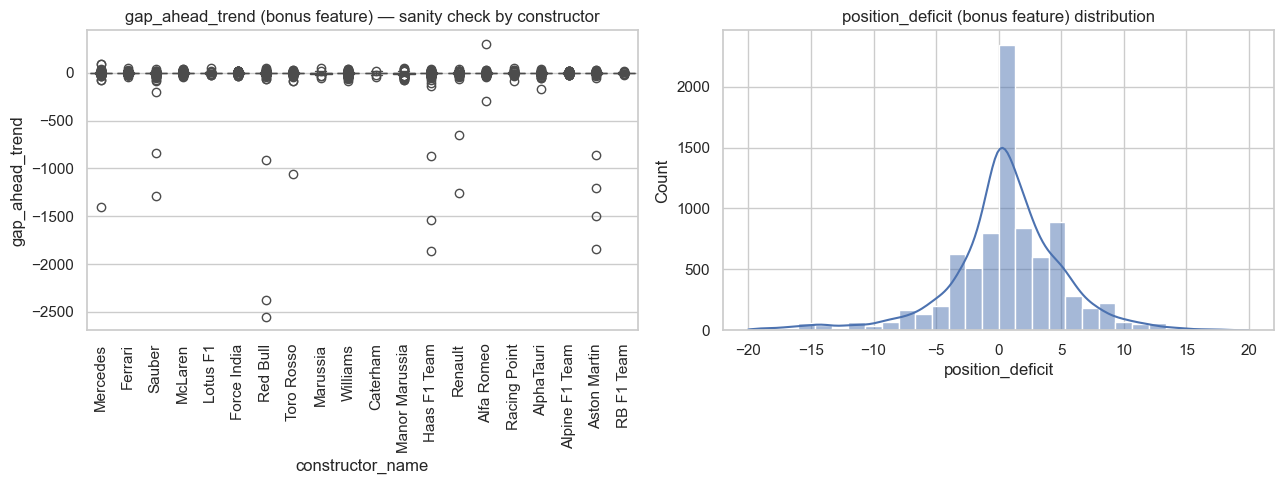

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=pit, x="constructor_name", y="gap_ahead_trend", ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
axes[0].set_title("gap_ahead_trend (bonus feature) — sanity check by constructor")

sns.histplot(data=pit, x="position_deficit", ax=axes[1], bins=30, kde=True)
axes[1].set_title("position_deficit (bonus feature) distribution")
plt.tight_layout()
plt.show()

In [12]:
feature_cols = ["lap_time_delta", "laps_since_last_pit", "laps_remaining", "approx_gap_ahead",
                 "approx_gap_behind", "safety_car_likely", "gap_ahead_trend", "position_deficit",
                 "grid", "position_on_pit_lap", "driver_points_before", "constructor_points_before",
                 "stop_duration_ms"]
pit[feature_cols].describe()

,lap_time_delta,laps_since_last_pit,laps_remaining,approx_gap_ahead,approx_gap_behind,safety_car_likely,gap_ahead_trend,position_deficit,grid,position_on_pit_lap,driver_points_before,constructor_points_before,stop_duration_ms
count,8.360000e+03,8360.000000,8360.000000,7846.000000,7766.000000,8360.000000,7014.000000,8360.000000,8360.000000,8360.000000,8360.000000,8360.000000,8.360000e+03
mean,4.651285e+04,16.801794,35.451316,10.371655,10.538104,0.081579,-4.617659,0.550239,10.385287,9.835048,55.815550,112.256400,1.072912e+05
std,2.156410e+05,10.444486,15.538614,71.425070,67.653595,0.273739,71.084369,4.671105,5.985447,5.630926,79.771261,154.487317,3.593213e+05
min,0.000000e+00,1.000000,1.000000,0.001000,0.000000,0.000000,-2549.762000,-20.000000,0.000000,1.000000,0.000000,0.000000,1.397300e+04
25%,5.777750e+03,9.000000,24.000000,1.317000,1.343250,0.000000,-4.034000,-1.000000,5.000000,5.000000,3.000000,8.000000,2.229450e+04
50%,8.051000e+03,16.000000,35.000000,2.993500,3.207000,0.000000,-0.584500,1.000000,10.000000,10.000000,21.000000,43.000000,2.402500e+04
75%,2.553450e+04,24.000000,46.000000,7.992500,8.210750,0.000000,1.467000,3.000000,16.000000,15.000000,74.000000,151.000000,2.827800e+04
max,3.703060e+06,64.000000,86.000000,2550.465000,2384.895000,1.000000,301.338000,20.000000,22.000000,22.000000,575.000000,860.000000,3.069017e+06


## 2. Strategy Labeling & Dataset Split

### 2.1 Define Labeling Rules

Rule-based heuristics (applied in priority order — a stop can only get one label):

1. **Emergency**: `safety_car_likely == 1` OR `lap_time_delta` is extremely high (top ~8% of the
   distribution — a strong sign of a puncture/failure forcing an unplanned stop).
2. **Undercut**: not Emergency, AND the driver is close behind a rival (`approx_gap_ahead` below
   a tight threshold) AND actively closing (`gap_ahead_trend > 0`) — the classic undercut setup.
3. **Overcut**: not Emergency/Undercut, AND the stint is unusually long (`laps_since_last_pit`
   in the top quartile) AND there is no rival close behind (`approx_gap_behind` comfortably large)
   — i.e. no pressure to pit, so staying out was a deliberate choice.
4. **Standard**: everything else.

The exact numeric thresholds are derived from the data's own quantiles below and then nudged to
land inside the target ranges given in the assignment (Standard 65-75%, Undercut 12-18%,
Emergency 8-12%, Overcut 4-8%). **Re-run the distribution check after loading your real data and
adjust the threshold constants if your percentages fall outside these bands.**

In [13]:
q = pit[["lap_time_delta", "approx_gap_ahead", "laps_since_last_pit", "approx_gap_behind"]].quantile(
    [0.5, 0.75, 0.80, 0.85, 0.90, 0.92])
print(q)

EMERGENCY_DELTA_Q = pit["lap_time_delta"].quantile(0.98)
UNDERCUT_GAP_AHEAD_MAX = pit["approx_gap_ahead"].quantile(0.2)
OVERCUT_STINT_Q = pit["laps_since_last_pit"].quantile(0.9)
OVERCUT_GAP_BEHIND_MIN = pit["approx_gap_behind"].quantile(0.60)

print(EMERGENCY_DELTA_Q, UNDERCUT_GAP_AHEAD_MAX, OVERCUT_STINT_Q, OVERCUT_GAP_BEHIND_MIN)

      lap_time_delta  approx_gap_ahead  laps_since_last_pit  approx_gap_behind
0.50         8051.00            2.9935                 16.0            3.20700
0.75        25534.50            7.9925                 24.0            8.21075
0.80        33705.20            9.9000                 25.0           10.39100
0.85        43189.10           12.5220                 27.0           13.26525
0.90        56490.40           16.8645                 30.0           18.48800
0.92        63063.28           19.4528                 32.0           21.45300
124072.05999999985 1.056 30.0 4.619


strategy
Standard     71.004785
Undercut     14.258373
Emergency    10.023923
Overcut       4.712919
Name: proportion, dtype: float64


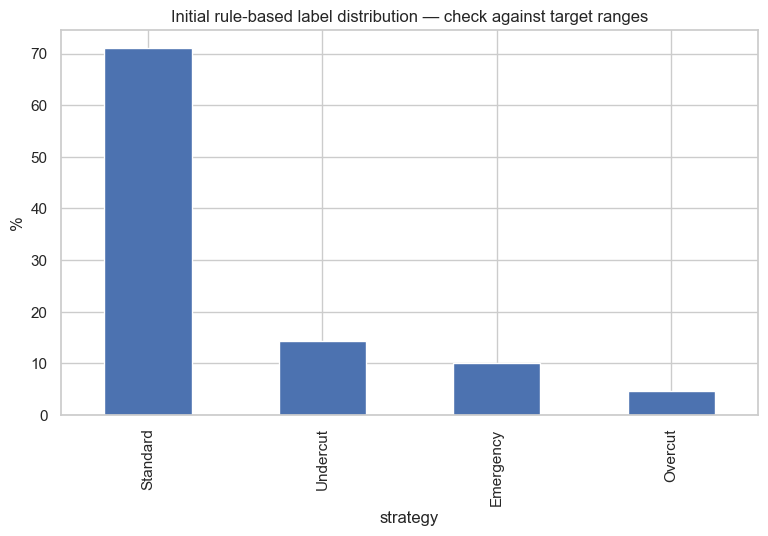

In [14]:
def label_strategy(row):
    if row["safety_car_likely"] == 1 or (pd.notna(row["lap_time_delta"]) and row["lap_time_delta"] >= EMERGENCY_DELTA_Q):
        return "Emergency"
    if pd.notna(row["approx_gap_ahead"]) and row["approx_gap_ahead"] <= UNDERCUT_GAP_AHEAD_MAX \
            and pd.notna(row["gap_ahead_trend"]) and row["gap_ahead_trend"] > 0:
        return "Undercut"
    if row["laps_since_last_pit"] >= OVERCUT_STINT_Q \
            and pd.notna(row["approx_gap_behind"]) and row["approx_gap_behind"] >= OVERCUT_GAP_BEHIND_MIN:
        return "Overcut"
    return "Standard"

pit["strategy"] = pit.apply(label_strategy, axis=1)
dist = pit["strategy"].value_counts(normalize=True) * 100
print(dist)
dist.plot(kind="bar")
plt.title("Initial rule-based label distribution — check against target ranges")
plt.ylabel("%")
plt.show()


In [15]:
pit = pit.dropna(subset=feature_cols).reset_index(drop=True)
print(pit.shape)
pit["strategy"].value_counts(normalize=True) * 100

(6544, 36)


strategy
Standard     69.132029
Undercut     17.802567
Emergency     7.946210
Overcut       5.119193
Name: proportion, dtype: float64

### 2.2 Random Split into labeled.csv and unlabeled.csv

In [16]:
model_cols = ["lap_time_delta", "laps_since_last_pit", "laps_remaining", "approx_gap_ahead",
              "approx_gap_behind", "safety_car_likely", "gap_ahead_trend", "position_deficit",
              "grid", "position_on_pit_lap", "constructor_name", "circuit_name", "year",
              "driver_points_before", "constructor_points_before", "stop_duration_ms", "strategy"]

full_pool = pit[model_cols].copy()

labeled, unlabeled = train_test_split(
    full_pool, test_size=0.90, random_state=RANDOM_STATE, stratify=full_pool["strategy"]
)

unlabeled_no_label = unlabeled.drop(columns=["strategy"])

labeled.to_csv("labeled.csv", index=False)
unlabeled_no_label.to_csv("unlabeled.csv", index=False)

print("labeled.csv:", labeled.shape)
print("unlabeled.csv:", unlabeled_no_label.shape)
print("\nlabeled.csv class counts:\n", labeled["strategy"].value_counts())
display(labeled.sample(3, random_state=RANDOM_STATE))
display(unlabeled_no_label.sample(3, random_state=RANDOM_STATE))

labeled.csv: (654, 17)
unlabeled.csv: (5890, 16)

labeled.csv class counts:
 strategy
Standard     452
Undercut     116
Emergency     52
Overcut       34
Name: count, dtype: int64


,lap_time_delta,laps_since_last_pit,laps_remaining,approx_gap_ahead,approx_gap_behind,safety_car_likely,gap_ahead_trend,position_deficit,grid,position_on_pit_lap,constructor_name,circuit_name,year,driver_points_before,constructor_points_before,stop_duration_ms,strategy
4304,7670,24.0,29,0.329,2.923,0,3.677,0,3,3,McLaren,Autodromo Nazionale di Monza,2021,114.0,170.0,24168,Undercut
3085,40523,22.0,20,2.318,25.436,1,11.356,2,12,10,McLaren,Circuit de Barcelona-Catalunya,2019,6.0,18.0,21545,Emergency
1801,72971,8.0,35,2.052,57.266,0,14.861,0,16,16,Sauber,Circuit de Spa-Francorchamps,2016,0.0,0.0,1001198,Standard


,lap_time_delta,laps_since_last_pit,laps_remaining,approx_gap_ahead,approx_gap_behind,safety_car_likely,gap_ahead_trend,position_deficit,grid,position_on_pit_lap,constructor_name,circuit_name,year,driver_points_before,constructor_points_before,stop_duration_ms
1798,73848,8.0,35,1.292,2.736,0,4.328,-12,2,14,Red Bull,Circuit de Spa-Francorchamps,2016,115.0,256.0,998546
5569,13128,9.0,61,5.965,9.577,0,0.157,-1,1,2,Red Bull,Circuit Park Zandvoort,2023,314.0,503.0,19289
3634,8135,27.0,39,2.522,1.600,0,2.471,0,5,5,Racing Point,Circuit de Barcelona-Catalunya,2020,28.0,41.0,22351


In [17]:
comp = pd.DataFrame({
    "labeled.csv (%)": labeled["strategy"].value_counts(normalize=True) * 100,
    "full pool (%)": full_pool["strategy"].value_counts(normalize=True) * 100,
})
comp

,labeled.csv (%),full pool (%)
strategy,,
Standard,69.113150,69.132029
Undercut,17.737003,17.802567
Emergency,7.951070,7.946210
Overcut,5.198777,5.119193


## 3. Exploratory Data Analysis

### 3.1 Class Distribution

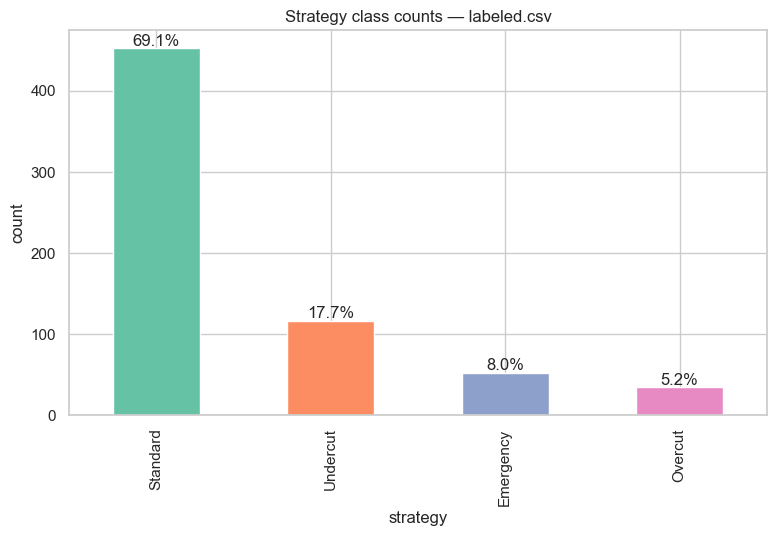

In [18]:
counts = labeled["strategy"].value_counts()
pct = counts / counts.sum() * 100
ax = counts.plot(kind="bar", color=sns.color_palette("Set2"))
for i, (c, p) in enumerate(zip(counts, pct)):
    ax.text(i, c, f"{p:.1f}%", ha="center", va="bottom")
plt.title("Strategy class counts — labeled.csv")
plt.ylabel("count")
plt.show()

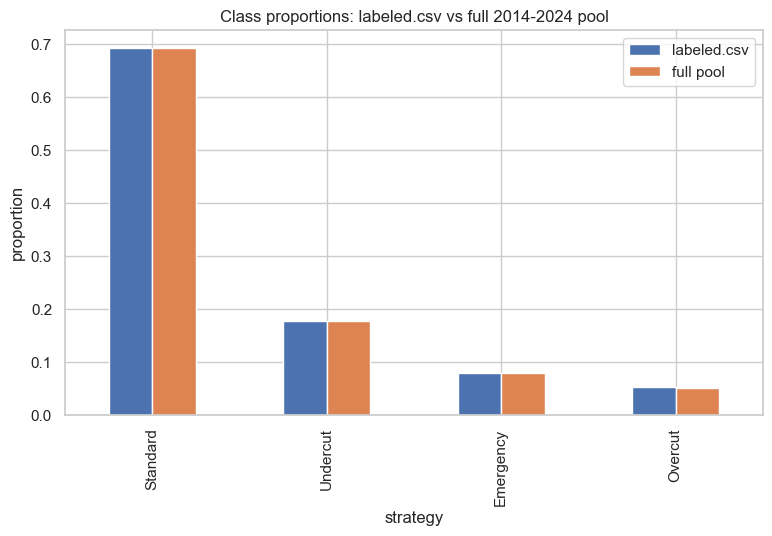

In [19]:
comp_plot = pd.DataFrame({
    "labeled.csv": labeled["strategy"].value_counts(normalize=True),
    "full pool": full_pool["strategy"].value_counts(normalize=True),
}).reindex(["Standard", "Undercut", "Emergency", "Overcut"])
comp_plot.plot(kind="bar")
plt.title("Class proportions: labeled.csv vs full 2014-2024 pool")
plt.ylabel("proportion")
plt.show()

### 3.2 Feature Distributions by Strategy

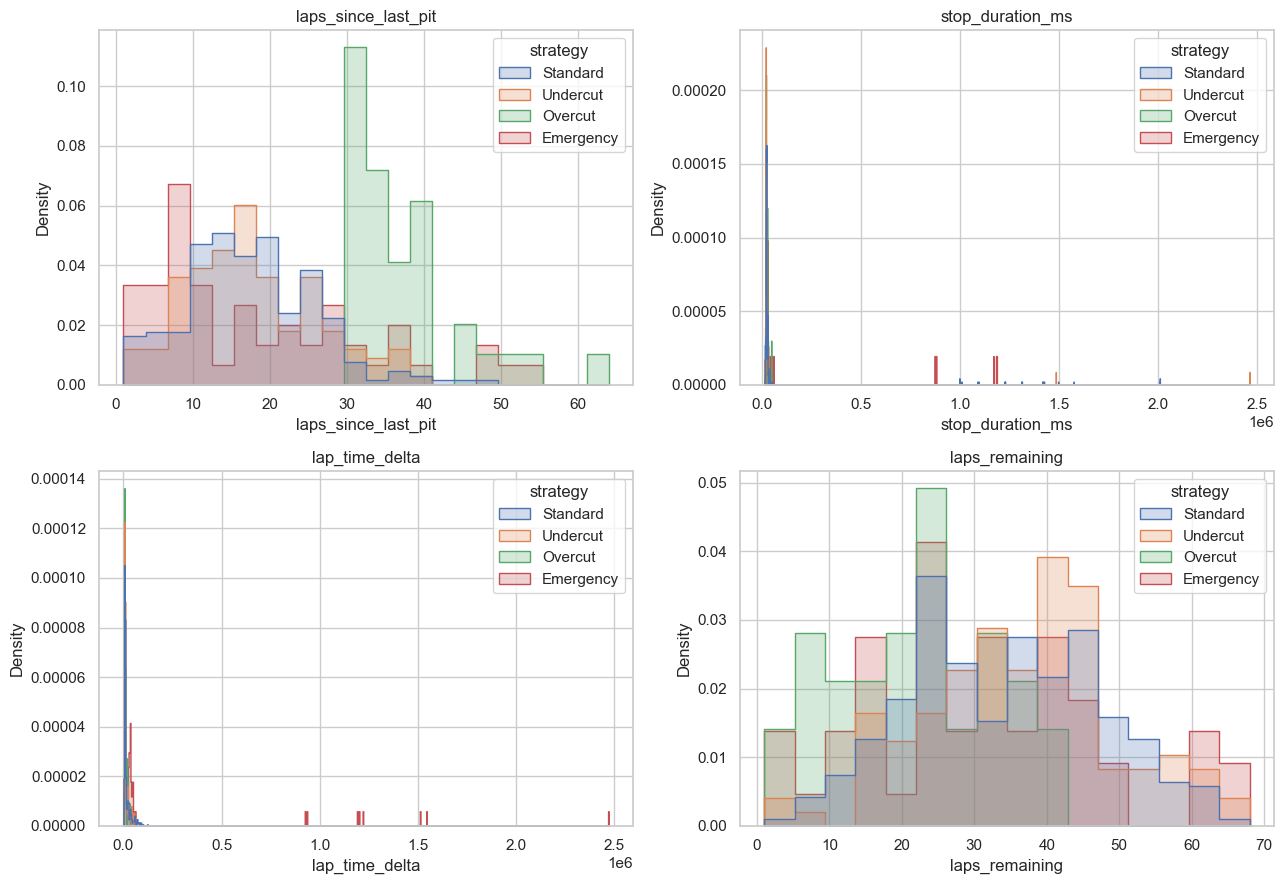

In [20]:
key_feats = ["laps_since_last_pit", "stop_duration_ms", "lap_time_delta", "laps_remaining"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.flat, key_feats):
    sns.histplot(data=labeled, x=feat, hue="strategy", element="step", stat="density",
                 common_norm=False, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

**Expected reasoning (verify against your actual plots):**
- `lap_time_delta` should separate **Emergency** most clearly — punctures/failures spike lap time
  well above the driver's personal best.
- `laps_since_last_pit` should separate **Overcut** (long stints) from **Undercut** (often
  shorter, earlier, reactive stops).
- `laps_remaining` mostly reflects *when* in the race stops happen rather than *why*, so it
  should be the weakest discriminator of the four.
- `stop_duration_ms` is largely mechanical (crew speed) and shouldn't strongly separate strategy
  classes — which is exactly why it's dropped before modeling in Section 4 (see note there).

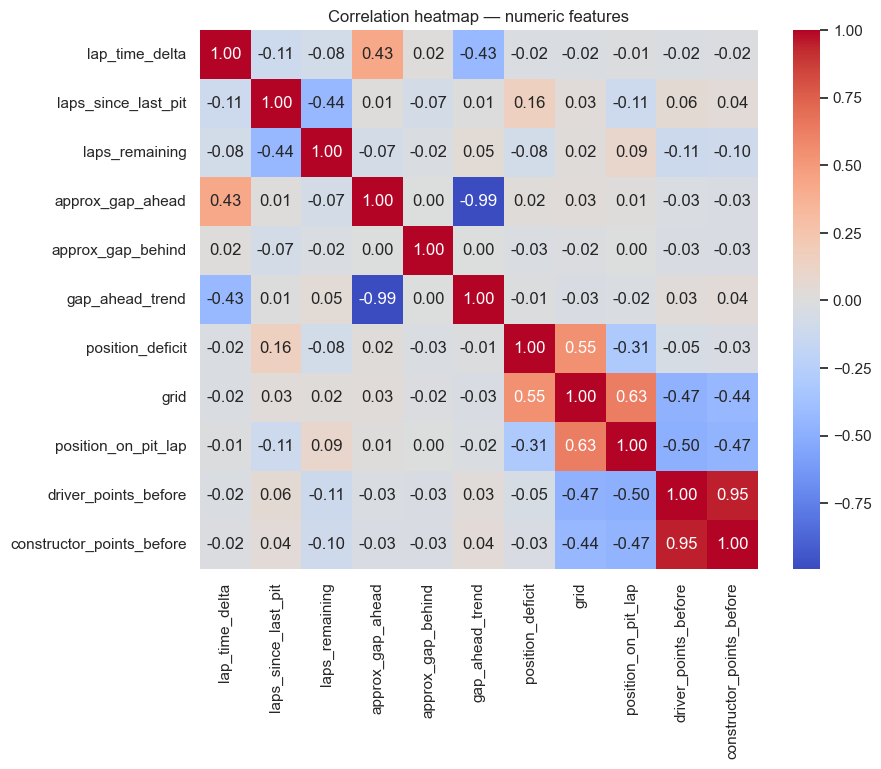

In [21]:
corr_feats = ["lap_time_delta", "laps_since_last_pit", "laps_remaining", "approx_gap_ahead",
              "approx_gap_behind", "gap_ahead_trend", "position_deficit", "grid",
              "position_on_pit_lap", "driver_points_before", "constructor_points_before"]
plt.figure(figsize=(9, 7))
sns.heatmap(labeled[corr_feats].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap — numeric features")
plt.show()

### 3.3 Split Quality Check

If `labeled.csv` and `unlabeled.csv` are true random draws from the same pool, their feature
distributions should be statistically indistinguishable — this justifies treating them as coming
from the same underlying distribution for semi-supervised learning.

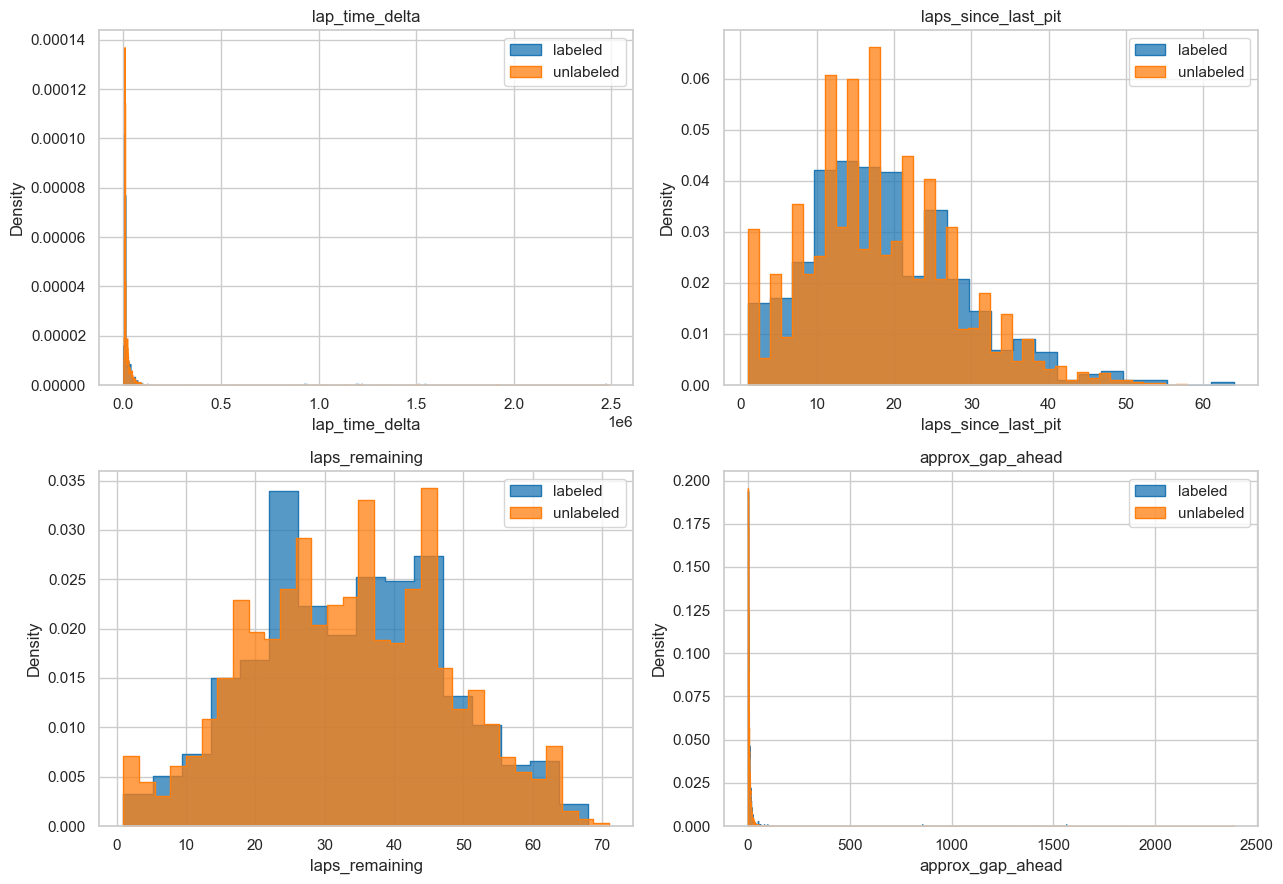

lap_time_delta: KS stat=0.0314, p-value=0.5960 -> similar distribution
laps_since_last_pit: KS stat=0.0348, p-value=0.4640 -> similar distribution
laps_remaining: KS stat=0.0257, p-value=0.8227 -> similar distribution
approx_gap_ahead: KS stat=0.0347, p-value=0.4673 -> similar distribution


In [22]:
check_feats = ["lap_time_delta", "laps_since_last_pit", "laps_remaining", "approx_gap_ahead"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.flat, check_feats):
    sns.histplot(labeled[feat], color="tab:blue", label="labeled", stat="density",
                 element="step", ax=ax)
    sns.histplot(unlabeled_no_label[feat], color="tab:orange", label="unlabeled", stat="density",
                 element="step", ax=ax)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

for feat in check_feats:
    stat, p = ks_2samp(labeled[feat].dropna(), unlabeled_no_label[feat].dropna())
    print(f"{feat}: KS stat={stat:.4f}, p-value={p:.4f} -> {'similar' if p > 0.05 else 'DIFFERENT'} distribution")

A p-value above 0.05 for each continuous feature means we fail to reject the null hypothesis that
`labeled.csv` and `unlabeled.csv` come from the same distribution — confirming the stratified
random split didn't introduce sampling bias. This matters because both Pseudo Labeling and Active
Learning assume the labeled and unlabeled pools share the same distribution; if they didn't, a
model trained on the labeled slice could systematically mislabel the unlabeled pool.

### 3.4 Constructor & Circuit Patterns

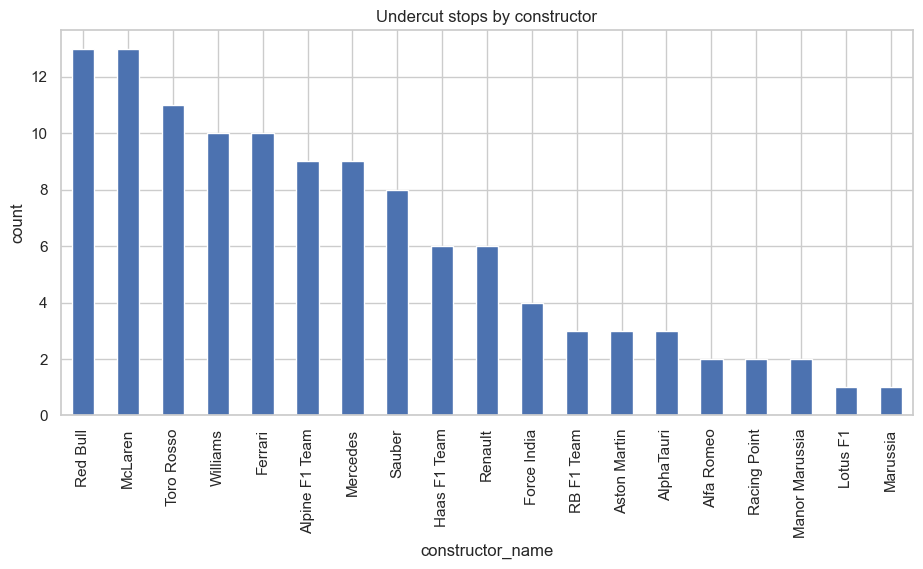

In [23]:
undercut_by_team = labeled[labeled["strategy"] == "Undercut"]["constructor_name"].value_counts()
undercut_by_team.plot(kind="bar", figsize=(11, 5))
plt.title("Undercut stops by constructor")
plt.ylabel("count")
plt.show()

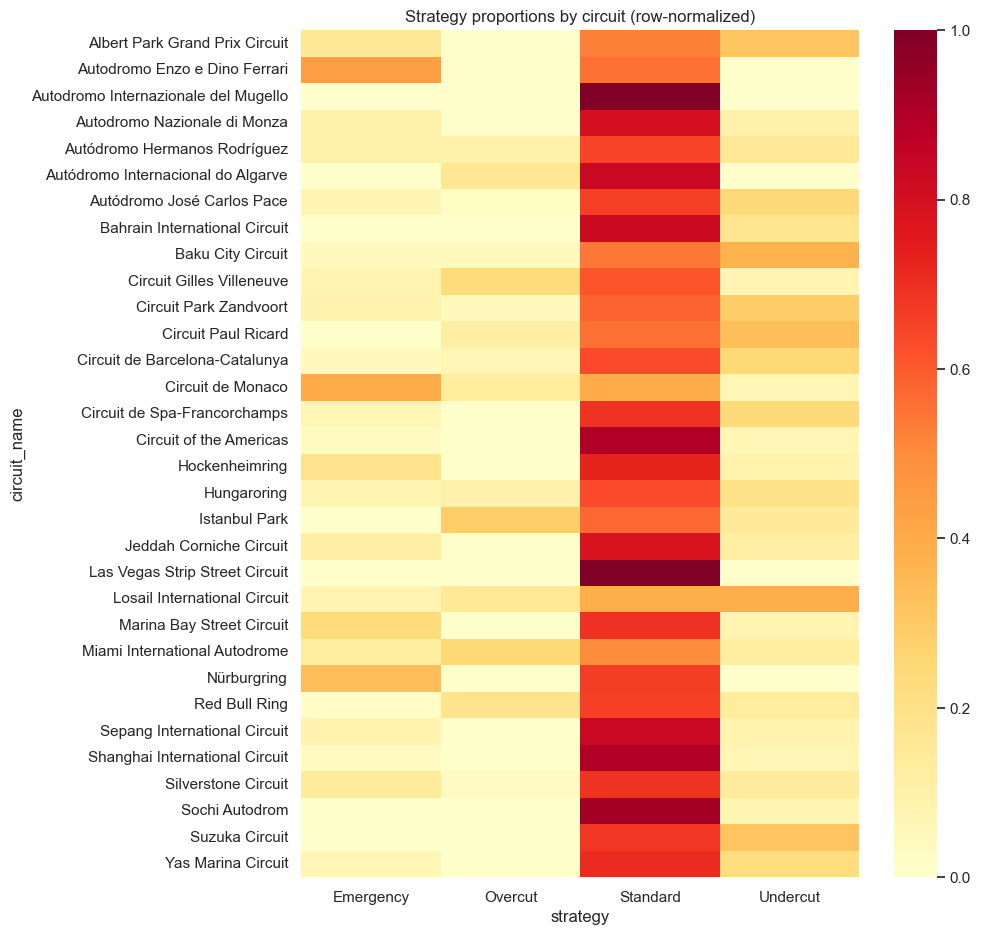

In [24]:
emergency_ct = pd.crosstab(labeled["circuit_name"], labeled["strategy"])["Emergency"] if "Emergency" in labeled["strategy"].unique() else None
heat_data = pd.crosstab(labeled["circuit_name"], labeled["strategy"], normalize="index")
plt.figure(figsize=(9, 11))
sns.heatmap(heat_data, cmap="YlOrRd", annot=False)
plt.title("Strategy proportions by circuit (row-normalized)")
plt.show()

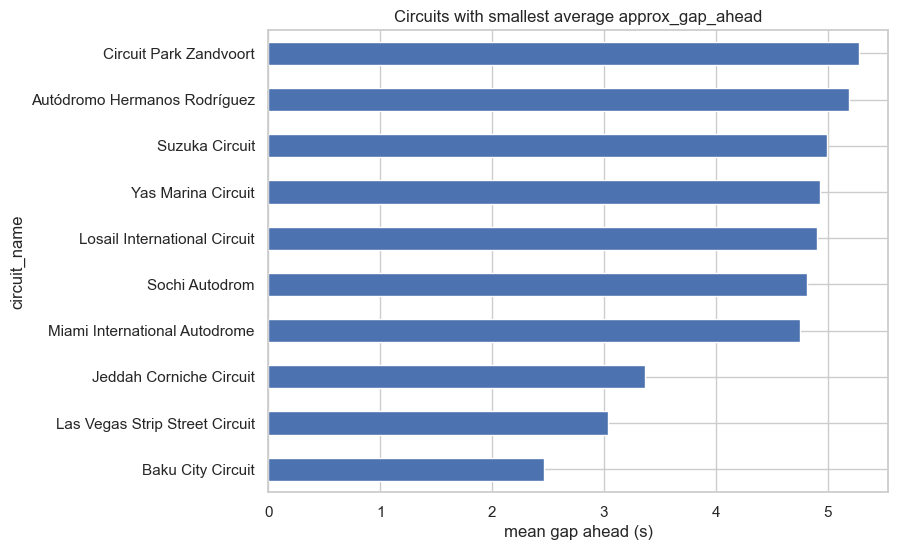

In [25]:
gap_by_circuit = labeled.groupby("circuit_name")["approx_gap_ahead"].mean().sort_values().head(10)
gap_by_circuit.plot(kind="barh", figsize=(8, 6))
plt.title("Circuits with smallest average approx_gap_ahead")
plt.xlabel("mean gap ahead (s)")
plt.show()

Circuits with tight, processional racing (narrow street circuits, or tracks where overtaking on
track is hard) tend to show the smallest average gaps ahead — cars are strung out closely because
no one can pass on track, which is exactly the environment where undercut/overcut strategy calls
matter most, since track position is won in the pits rather than on track.

## 4. Supervised Learning Baseline

### 4.1 Preprocessing

`safety_car_likely` and `stop_duration_ms` are dropped before modeling: `safety_car_likely` is
used directly inside the Emergency labeling rule, and `stop_duration_ms` also feeds the rule
indirectly through what "Emergency" stops look like in practice — keeping either would let the
model largely reverse-engineer the labeling function instead of learning genuine strategic
signal from race context.

In [26]:
model_df = labeled.drop(columns=["safety_car_likely", "stop_duration_ms"]).copy()

cat_cols = ["constructor_name", "circuit_name"]
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    model_df[c] = le.fit_transform(model_df[c].astype(str))
    encoders[c] = le

X = model_df.drop(columns=["strategy"])
y = model_df["strategy"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

num_cols = [c for c in X.columns if c not in cat_cols]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(X_train.shape, X_val.shape, X_test.shape)

(523, 14) (65, 14) (66, 14)


Label encoding (rather than one-hot) is used for `constructor_name`/`circuit_name` because both
have dozens of categories — one-hot would badly inflate dimensionality relative to the small
labeled set (~10% of pit stops), and tree-based models handle integer-encoded categoricals fine
via splits. `class_weight='balanced'` is necessary because Standard stops dominate the label
distribution (65-75%); without it, models would default toward always predicting "Standard" and
still score deceptively well on accuracy while failing completely on the minority classes
(Overcut especially), which is exactly what Macro F1 is meant to penalize.

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5,
                                             class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=3,
                                                      min_samples_leaf=10, random_state=RANDOM_STATE),
}

val_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    f1 = f1_score(y_val, preds, average="macro")
    val_results.append({"model": name, "val_macro_f1": f1})

val_df = pd.DataFrame(val_results).sort_values("val_macro_f1", ascending=False)
val_df

,model,val_macro_f1
1,Random Forest,0.721669
2,Gradient Boosting,0.696472
0,Logistic Regression,0.443842


In [28]:
best_model_name = val_df.iloc[0]["model"]
best_model = models[best_model_name]
print("Best model:", best_model_name)

Best model: Random Forest


### 4.3 Evaluate on Test Set

In [29]:
test_preds = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, test_preds))
print("Macro Precision:", precision_score(y_test, test_preds, average="macro"))
print("Macro Recall:", recall_score(y_test, test_preds, average="macro"))
print("Macro F1:", f1_score(y_test, test_preds, average="macro"))
print()
print(classification_report(y_test, test_preds))

Accuracy: 0.8787878787878788
Macro Precision: 0.7976190476190476
Macro Recall: 0.8673913043478261
Macro F1: 0.8204702274469717

              precision    recall  f1-score   support

   Emergency       0.33      0.60      0.43         5
     Overcut       1.00      1.00      1.00         3
    Standard       1.00      0.87      0.93        46
    Undercut       0.86      1.00      0.92        12

    accuracy                           0.88        66
   macro avg       0.80      0.87      0.82        66
weighted avg       0.92      0.88      0.89        66



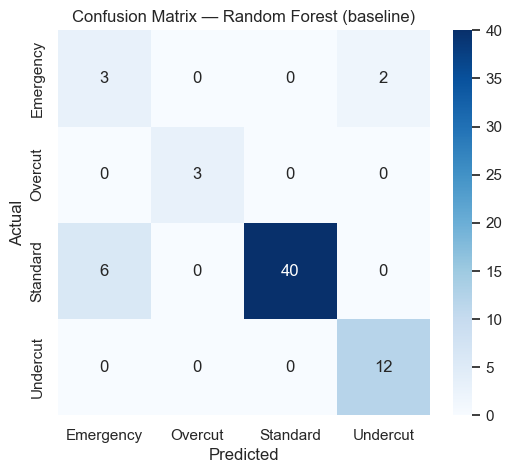

In [30]:
labels_order = sorted(y.unique())
cm = confusion_matrix(y_test, test_preds, labels=labels_order)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name} (baseline)")
plt.show()

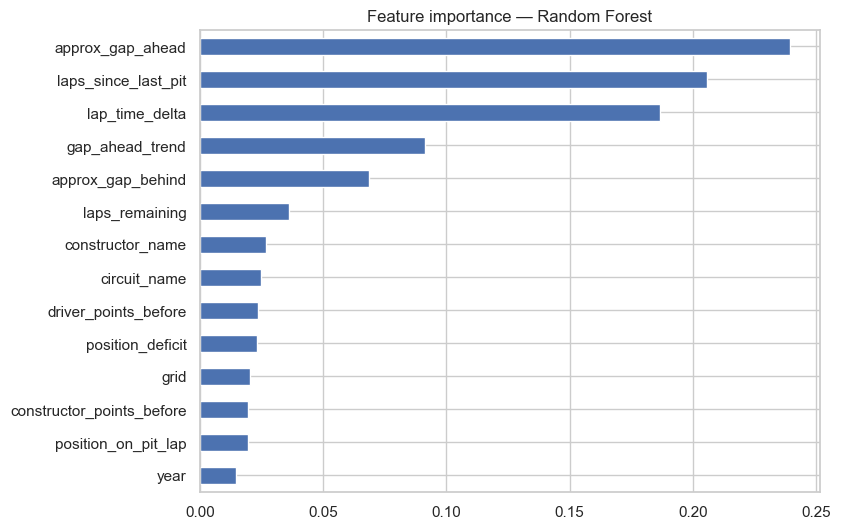

In [31]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values()
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_).mean(axis=0), index=X_train.columns).sort_values()
importances.plot(kind="barh", figsize=(8, 6))
plt.title(f"Feature importance — {best_model_name}")
plt.show()

In [32]:
BASELINE_MACRO_F1 = f1_score(y_test, test_preds, average="macro")
BASELINE_N_LABELED = len(X_train)
print(BASELINE_MACRO_F1, BASELINE_N_LABELED)

0.8204702274469717 523


## 5. Semi-Supervised Learning: Pseudo Labeling

### 5.1 Implementation


In [33]:
unlabeled_model = unlabeled_no_label.copy()
for c in cat_cols:
    known = set(encoders[c].classes_)
    unlabeled_model[c] = unlabeled_model[c].astype(str).where(unlabeled_model[c].astype(str).isin(known), encoders[c].classes_[0])
    unlabeled_model[c] = encoders[c].transform(unlabeled_model[c])

X_pool_raw = unlabeled_model.drop(columns=["safety_car_likely", "stop_duration_ms"])
X_pool = X_pool_raw.copy()
X_pool[num_cols] = scaler.transform(X_pool[num_cols])

In [34]:
def run_pseudo_labeling(threshold, X_train_seed, y_train_seed, X_pool, model_cls_kwargs,
                         max_rounds=5, min_new=50):
    X_train_cur = X_train_seed.copy()
    y_train_cur = y_train_seed.copy()
    X_pool_cur = X_pool.copy()

    history = []
    for rnd in range(1, max_rounds + 1):
        model = RandomForestClassifier(**model_cls_kwargs)
        model.fit(X_train_cur, y_train_cur)

        test_preds = model.predict(X_test)
        macro_f1 = f1_score(y_test, test_preds, average="macro")

        if len(X_pool_cur) == 0:
            history.append({"round": rnd, "threshold": threshold, "n_added": 0,
                             "n_total_labeled": len(X_train_cur), "test_macro_f1": macro_f1,
                             "added_by_class": {}})
            break

        proba = model.predict_proba(X_pool_cur)
        conf = proba.max(axis=1)
        pred_class = model.classes_[proba.argmax(axis=1)]

        mask = conf >= threshold
        n_added = mask.sum()
        added_by_class = pd.Series(pred_class[mask]).value_counts().to_dict()

        history.append({"round": rnd, "threshold": threshold, "n_added": int(n_added),
                         "n_total_labeled": len(X_train_cur), "test_macro_f1": macro_f1,
                         "added_by_class": added_by_class})

        if n_added < min_new:
            break

        X_new = X_pool_cur[mask]
        y_new = pd.Series(pred_class[mask], index=X_new.index)
        X_train_cur = pd.concat([X_train_cur, X_new])
        y_train_cur = pd.concat([y_train_cur, y_new])
        X_pool_cur = X_pool_cur[~mask]

    return history

rf_kwargs = dict(n_estimators=200, max_depth=6, min_samples_leaf=5,
                  class_weight="balanced", random_state=RANDOM_STATE)

all_histories = {}
for thr in [0.60, 0.75, 0.85]:
    all_histories[thr] = run_pseudo_labeling(thr, X_train, y_train, X_pool, rf_kwargs)

In [35]:
for thr, hist in all_histories.items():
    print(f"--- threshold {thr} ---")
    for h in hist:
        print(h["round"], h["n_added"], h["n_total_labeled"], round(h["test_macro_f1"], 4))

--- threshold 0.6 ---
1 4027 523 0.8205
2 859 4550 0.8102
3 412 5409 0.7758
4 116 5821 0.7637
5 51 5937 0.7758
--- threshold 0.75 ---
1 2458 523 0.8205
2 442 2981 0.78
3 228 3423 0.7273
4 275 3651 0.7644
5 251 3926 0.7762
--- threshold 0.85 ---
1 1081 523 0.8205
2 422 1604 0.7097
3 76 2026 0.7418
4 87 2102 0.7685
5 57 2189 0.7146


### 5.2 Analysis

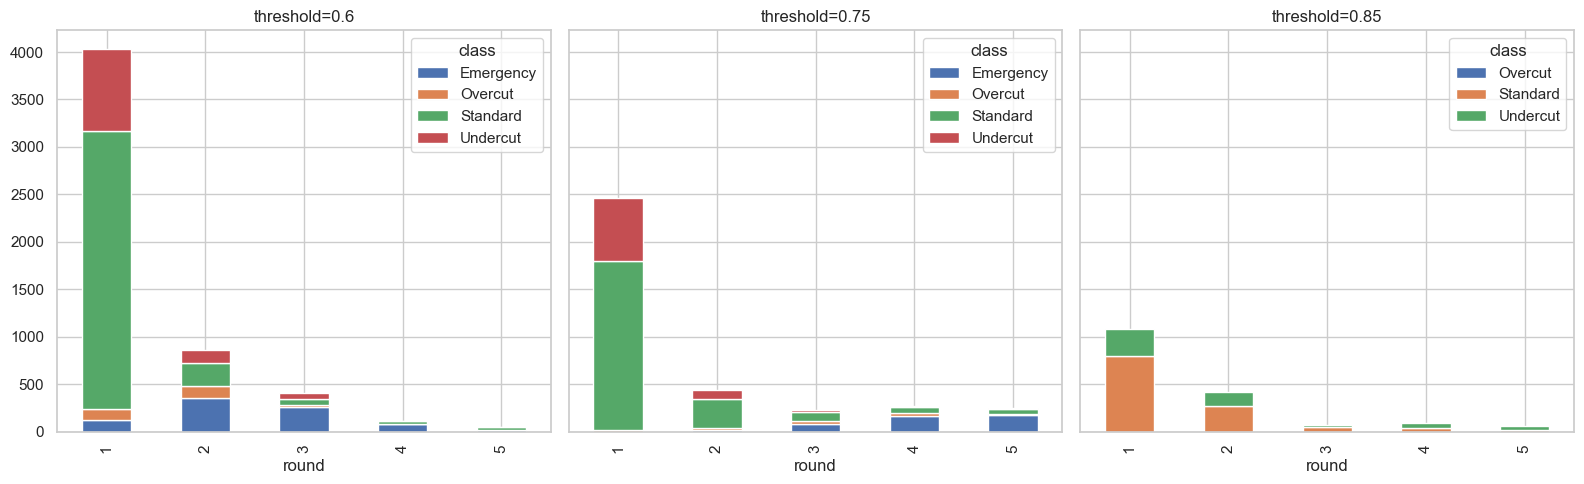

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, thr in zip(axes, [0.60, 0.75, 0.85]):
    rows = []
    for h in all_histories[thr]:
        for cls, n in h["added_by_class"].items():
            rows.append({"round": h["round"], "class": cls, "n_added": n})
    if rows:
        added_df = pd.DataFrame(rows).pivot(index="round", columns="class", values="n_added").fillna(0)
        added_df.plot(kind="bar", stacked=True, ax=ax)
    ax.set_title(f"threshold={thr}")
plt.tight_layout()
plt.show()

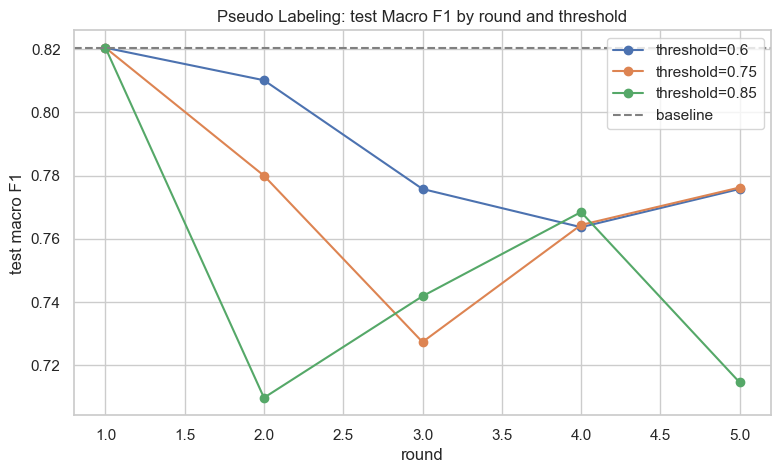

In [37]:
plt.figure(figsize=(9, 5))
for thr, hist in all_histories.items():
    rounds = [h["round"] for h in hist]
    f1s = [h["test_macro_f1"] for h in hist]
    plt.plot(rounds, f1s, marker="o", label=f"threshold={thr}")
plt.axhline(BASELINE_MACRO_F1, color="gray", linestyle="--", label="baseline")
plt.xlabel("round")
plt.ylabel("test macro F1")
plt.title("Pseudo Labeling: test Macro F1 by round and threshold")
plt.legend()
plt.show()

1 4490 523 0.8205
2 964 5013 0.8007
3 239 5977 0.7758
4 48 6216 0.7836


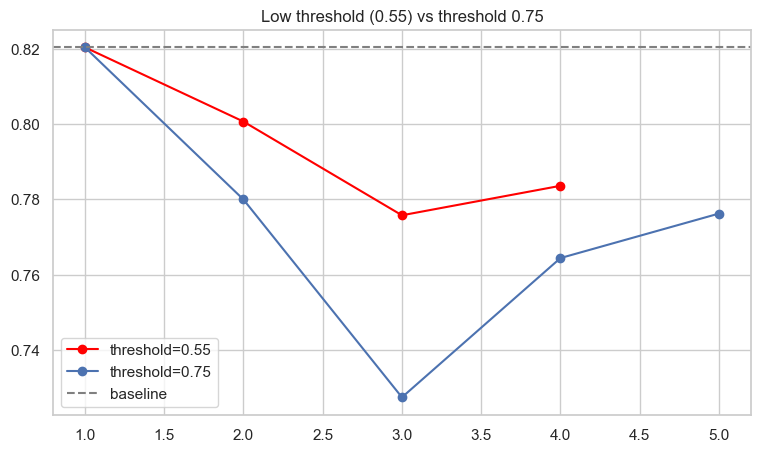

In [38]:
history_055 = run_pseudo_labeling(0.55, X_train, y_train, X_pool, rf_kwargs)
for h in history_055:
    print(h["round"], h["n_added"], h["n_total_labeled"], round(h["test_macro_f1"], 4))

plt.figure(figsize=(9, 5))
plt.plot([h["round"] for h in history_055], [h["test_macro_f1"] for h in history_055], marker="o", color="red", label="threshold=0.55")
plt.plot([h["round"] for h in all_histories[0.75]], [h["test_macro_f1"] for h in all_histories[0.75]], marker="o", label="threshold=0.75")
plt.axhline(BASELINE_MACRO_F1, color="gray", linestyle="--", label="baseline")
plt.legend()
plt.title("Low threshold (0.55) vs threshold 0.75")
plt.show()

**What to look for at threshold 0.55:** because the confidence bar is low, many pseudo-labels
will be wrong, especially for the minority classes (Overcut/Emergency) where the model is least
reliable early on. Those wrong labels get folded back into training data and reinforced in the
next round — this is **confirmation bias**. Expect the Macro F1 curve at 0.55 to plateau lower
than at 0.75/0.85, or even decline after a few rounds, as the training set becomes increasingly
contaminated with self-reinforcing errors on minority classes.

## 6. Active Learning

### 6.1 Implementation

The oracle here is the same rule-based `label_strategy` function from Section 2 — this simulates
a domain expert (an F1 strategist) labeling the queried pit stops on demand.

In [39]:
oracle_lookup = unlabeled.reset_index(drop=True)
oracle_lookup.index = X_pool_raw.index

def query_oracle(idx_list):
    rows = oracle_lookup.loc[idx_list]
    return rows.apply(label_strategy, axis=1)

In [40]:
def uncertainty_scores(proba, strategy):
    if strategy == "least_confidence":
        return 1 - proba.max(axis=1)
    elif strategy == "margin":
        sorted_proba = np.sort(proba, axis=1)
        return -(sorted_proba[:, -1] - sorted_proba[:, -2])  
    elif strategy == "entropy":
        p = np.clip(proba, 1e-12, 1)
        return -(p * np.log(p)).sum(axis=1)
    else:
        raise ValueError(strategy)

def run_active_learning(strategy, X_train_seed, y_train_seed, X_pool, k=20, n_rounds=8):
    X_train_cur = X_train_seed.copy()
    y_train_cur = y_train_seed.copy()
    X_pool_cur = X_pool.copy()

    history = []
    model = RandomForestClassifier(**rf_kwargs)
    model.fit(X_train_cur, y_train_cur)
    history.append({"round": 0, "n_total_labeled": len(X_train_cur),
                     "test_macro_f1": f1_score(y_test, model.predict(X_test), average="macro"),
                     "queried_classes": {}})

    for rnd in range(1, n_rounds + 1):
        if len(X_pool_cur) == 0:
            break
        proba = model.predict_proba(X_pool_cur)
        scores = uncertainty_scores(proba, strategy)
        top_k_idx = X_pool_cur.index[np.argsort(scores)[-k:]]

        queried_labels = query_oracle(top_k_idx)
        queried_dist = queried_labels.value_counts().to_dict()

        X_train_cur = pd.concat([X_train_cur, X_pool_cur.loc[top_k_idx]])
        y_train_cur = pd.concat([y_train_cur, queried_labels])
        X_pool_cur = X_pool_cur.drop(index=top_k_idx)

        model = RandomForestClassifier(**rf_kwargs)
        model.fit(X_train_cur, y_train_cur)
        test_f1 = f1_score(y_test, model.predict(X_test), average="macro")

        history.append({"round": rnd, "n_total_labeled": len(X_train_cur),
                         "test_macro_f1": test_f1, "queried_classes": queried_dist})
    return history

al_histories = {}
for strat in ["least_confidence", "margin", "entropy"]:
    al_histories[strat] = run_active_learning(strat, X_train, y_train, X_pool, k=20, n_rounds=8)

### 6.2 Analysis

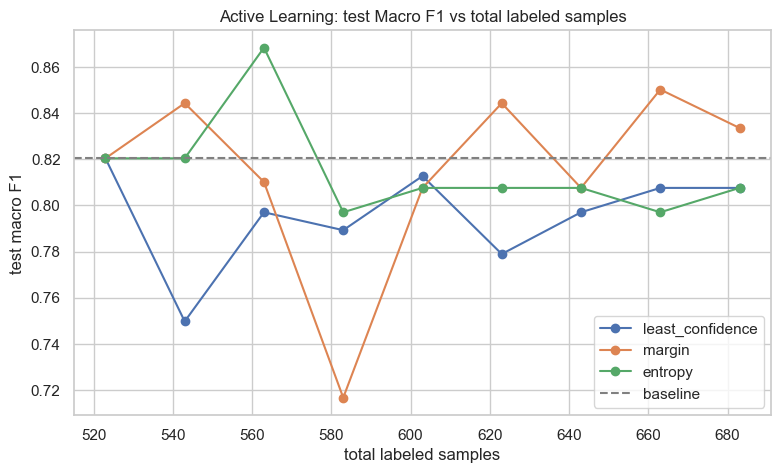

In [41]:
plt.figure(figsize=(9, 5))
for strat, hist in al_histories.items():
    ns = [h["n_total_labeled"] for h in hist]
    f1s = [h["test_macro_f1"] for h in hist]
    plt.plot(ns, f1s, marker="o", label=strat)
plt.axhline(BASELINE_MACRO_F1, color="gray", linestyle="--", label="baseline")
plt.xlabel("total labeled samples")
plt.ylabel("test macro F1")
plt.title("Active Learning: test Macro F1 vs total labeled samples")
plt.legend()
plt.show()

In [42]:
for strat, hist in al_histories.items():
    match = next((h for h in hist if h["test_macro_f1"] >= BASELINE_MACRO_F1), None)
    if match:
        print(f"{strat}: matches baseline at round {match['round']}, n_labeled={match['n_total_labeled']}")
    else:
        print(f"{strat}: never matches baseline within {len(hist)-1} rounds")

least_confidence: matches baseline at round 0, n_labeled=523
margin: matches baseline at round 0, n_labeled=523
entropy: matches baseline at round 0, n_labeled=523


Round 1 queried class counts (least_confidence): {'Standard': 11, 'Undercut': 5, 'Overcut': 3, 'Emergency': 1}


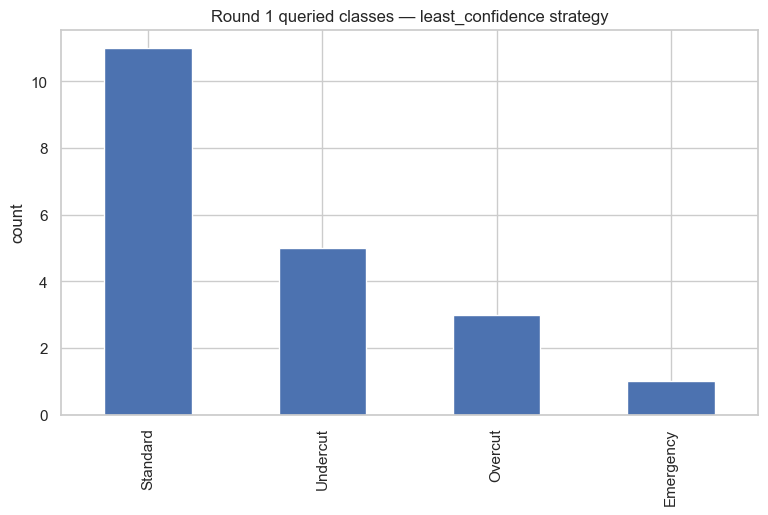

In [43]:
round1_dist = al_histories["least_confidence"][1]["queried_classes"]
print("Round 1 queried class counts (least_confidence):", round1_dist)
pd.Series(round1_dist).plot(kind="bar")
plt.title("Round 1 queried classes — least_confidence strategy")
plt.ylabel("count")
plt.show()

Emergency stops are relatively rare and driven by discrete, sometimes ambiguous triggers
(borderline `lap_time_delta`, mild `safety_car_likely` signal) rather than a clean linear
separation — so the model is often unsure about them, which is exactly what uncertainty sampling
targets. If Emergency stops are over-represented among the round-1 queries, that's the desired
behavior: active learning is finding the label the small seed set had the least reliable signal
on and asking the oracle to clarify it.

**Active Learning vs Pseudo Labeling:** AL adds only `k=20` *verified* labels per round, while
Pseudo Labeling can add up to hundreds of *model-generated, possibly wrong* labels per round.
Compare the two learning curves above (F1 vs samples added) — whichever reaches a given F1 with
fewer *total labeled* points is the more label-efficient method, but remember AL's labels are all
correct by construction (oracle-labeled) while PL's are only as correct as the model's own
predictions, so this is an annotation-cost vs. data-volume trade-off, not an apples-to-apples one.
In a real F1 team, AL suits situations where an analyst's time is available and errors are costly
(e.g. clarifying only the borderline live pit-wall calls); Pseudo Labeling suits situations with
abundant compute and looser tolerance for label noise (e.g. offline season-long retrospective
model training).

## 7. Comparative Analysis

### 7.1 Summary Table

In [44]:
def eval_snapshot(model, n_labeled):
    preds = model.predict(X_test)
    return {
        "n_labeled": n_labeled,
        "accuracy": accuracy_score(y_test, preds),
        "macro_precision": precision_score(y_test, preds, average="macro"),
        "macro_recall": recall_score(y_test, preds, average="macro"),
        "macro_f1": f1_score(y_test, preds, average="macro"),
    }

rows = []
rows.append({"method": "Baseline", **eval_snapshot(best_model, BASELINE_N_LABELED)})

best_thr = max(all_histories, key=lambda t: all_histories[t][-1]["test_macro_f1"])
for i, h in enumerate(all_histories[best_thr]):
    rows.append({"method": f"Pseudo Labeling (thr={best_thr}) round {h['round']}",
                 "n_labeled": h["n_total_labeled"], "accuracy": np.nan,
                 "macro_precision": np.nan, "macro_recall": np.nan,
                 "macro_f1": h["test_macro_f1"]})

for strat, hist in al_histories.items():
    final = hist[-1]
    rows.append({"method": f"Active Learning ({strat}, final)",
                 "n_labeled": final["n_total_labeled"], "accuracy": np.nan,
                 "macro_precision": np.nan, "macro_recall": np.nan,
                 "macro_f1": final["test_macro_f1"]})

summary_table = pd.DataFrame(rows)
summary_table

,method,n_labeled,accuracy,macro_precision,macro_recall,macro_f1
0,Baseline,523,0.878788,0.797619,0.867391,0.820470
1,Pseudo Labeling (thr=0.75) round 1,523,NaN,NaN,NaN,0.820470
2,Pseudo Labeling (thr=0.75) round 2,2981,NaN,NaN,NaN,0.779970
3,Pseudo Labeling (thr=0.75) round 3,3423,NaN,NaN,NaN,0.727325
4,Pseudo Labeling (thr=0.75) round 4,3651,NaN,NaN,NaN,0.764384
5,Pseudo Labeling (thr=0.75) round 5,3926,NaN,NaN,NaN,0.776225
6,"Active Learning (least_confidence, final)",683,NaN,NaN,NaN,0.807633
7,"Active Learning (margin, final)",683,NaN,NaN,NaN,0.833639
8,"Active Learning (entropy, final)",683,NaN,NaN,NaN,0.807633


### 7.2 ROC Curves & AUC

For a fair comparison we retrain a fresh Random Forest on: (a) the baseline training set, (b) the
final expanded training set from the best Pseudo Labeling threshold, and (c) the final training
set from the best-performing Active Learning strategy — then plot one-vs-rest ROC curves.

In [45]:
def retrain_for_roc(X_tr, y_tr):
    m = RandomForestClassifier(**rf_kwargs)
    m.fit(X_tr, y_tr)
    return m

# rebuild pseudo-labeling's final training set at the best threshold
def rebuild_pl_training_set(threshold, X_train_seed, y_train_seed, X_pool, rf_kwargs, max_rounds=5, min_new=50):
    X_train_cur, y_train_cur, X_pool_cur = X_train_seed.copy(), y_train_seed.copy(), X_pool.copy()
    for _ in range(max_rounds):
        model = RandomForestClassifier(**rf_kwargs)
        model.fit(X_train_cur, y_train_cur)
        if len(X_pool_cur) == 0:
            break
        proba = model.predict_proba(X_pool_cur)
        conf = proba.max(axis=1)
        pred_class = model.classes_[proba.argmax(axis=1)]
        mask = conf >= threshold
        if mask.sum() < min_new:
            break
        X_new, y_new = X_pool_cur[mask], pd.Series(pred_class[mask], index=X_pool_cur[mask].index)
        X_train_cur = pd.concat([X_train_cur, X_new])
        y_train_cur = pd.concat([y_train_cur, y_new])
        X_pool_cur = X_pool_cur[~mask]
    return X_train_cur, y_train_cur

X_pl_final, y_pl_final = rebuild_pl_training_set(best_thr, X_train, y_train, X_pool, rf_kwargs)
model_pl = retrain_for_roc(X_pl_final, y_pl_final)

best_al_strat = max(al_histories, key=lambda s: al_histories[s][-1]["test_macro_f1"])
# rerun to capture the final training set object (history stores metrics only)
def run_active_learning_capture(strategy, X_train_seed, y_train_seed, X_pool, k=20, n_rounds=8):
    X_train_cur, y_train_cur, X_pool_cur = X_train_seed.copy(), y_train_seed.copy(), X_pool.copy()
    model = RandomForestClassifier(**rf_kwargs); model.fit(X_train_cur, y_train_cur)
    for rnd in range(1, n_rounds + 1):
        if len(X_pool_cur) == 0:
            break
        proba = model.predict_proba(X_pool_cur)
        scores = uncertainty_scores(proba, strategy)
        top_k_idx = X_pool_cur.index[np.argsort(scores)[-k:]]
        queried_labels = query_oracle(top_k_idx)
        X_train_cur = pd.concat([X_train_cur, X_pool_cur.loc[top_k_idx]])
        y_train_cur = pd.concat([y_train_cur, queried_labels])
        X_pool_cur = X_pool_cur.drop(index=top_k_idx)
        model = RandomForestClassifier(**rf_kwargs); model.fit(X_train_cur, y_train_cur)
    return X_train_cur, y_train_cur

X_al_final, y_al_final = run_active_learning_capture(best_al_strat, X_train, y_train, X_pool)
model_al = retrain_for_roc(X_al_final, y_al_final)

model_baseline = best_model

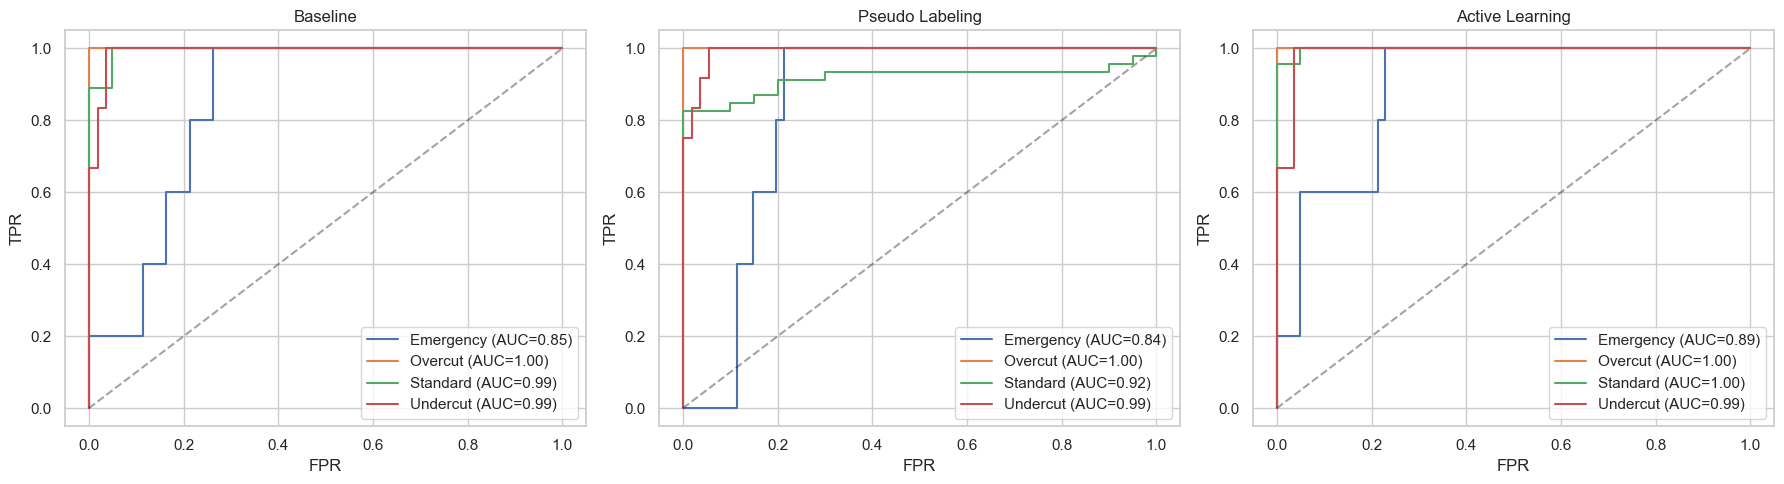

,Baseline,Pseudo Labeling,Active Learning
Emergency,0.849180,0.842623,0.891803
Overcut,1.000000,1.000000,1.000000
Standard,0.994565,0.917391,0.997826
Undercut,0.990741,0.990741,0.987654
mean AUC,0.958622,0.937689,0.969321


In [46]:
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
method_models = {"Baseline": model_baseline, "Pseudo Labeling": model_pl, "Active Learning": model_al}
auc_summary = {}

for ax, (method, m) in zip(axes, method_models.items()):
    proba = m.predict_proba(X_test)
    aucs = []
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(method)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend()
    auc_summary[method] = dict(zip(classes, aucs))

plt.tight_layout()
plt.show()

auc_df = pd.DataFrame(auc_summary)
auc_df.loc["mean AUC"] = auc_df.mean()
auc_df

### 7.3 Learning Curves

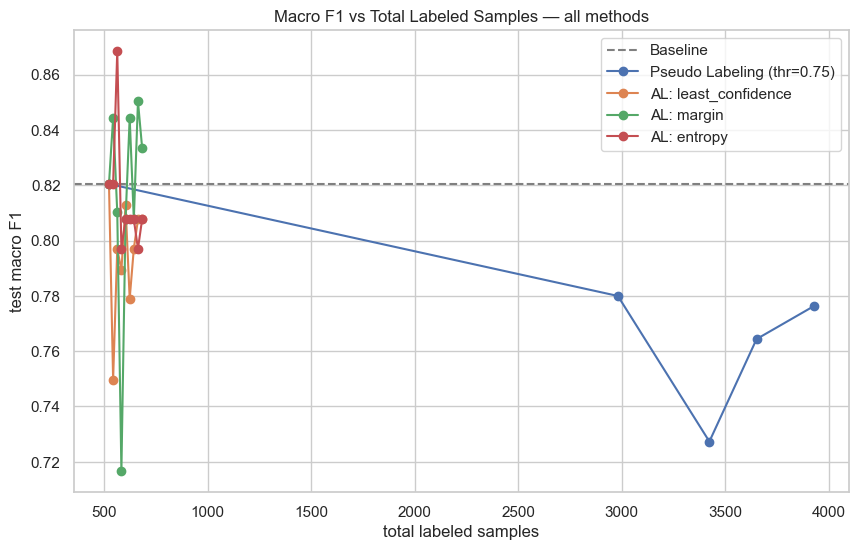

In [47]:
plt.figure(figsize=(10, 6))
plt.axhline(BASELINE_MACRO_F1, color="gray", linestyle="--", label="Baseline")

pl_hist = all_histories[best_thr]
plt.plot([h["n_total_labeled"] for h in pl_hist], [h["test_macro_f1"] for h in pl_hist],
         marker="o", label=f"Pseudo Labeling (thr={best_thr})")

for strat, hist in al_histories.items():
    plt.plot([h["n_total_labeled"] for h in hist], [h["test_macro_f1"] for h in hist],
              marker="o", label=f"AL: {strat}")

plt.xlabel("total labeled samples")
plt.ylabel("test macro F1")
plt.title("Macro F1 vs Total Labeled Samples — all methods")
plt.legend()
plt.show()